In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Load featured data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Data loaded successfully!
Shape: (500000, 32)

Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'month', 'year', 'weekday', 'wday', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI', 'avg_price', 'day', 'week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'has_event', 'is_snap', 'revenue', 'sales_lag_1', 'sales_lag_7', 'sales_lag_28', 'sales_rolling_7', 'sales_rolling_28']


In [2]:
# Prepare features for LightGBM
feature_cols = ['month', 'year', 'wday', 'day', 'week', 'quarter',
                'is_weekend', 'is_month_start', 'is_month_end',
                'has_event', 'is_snap', 'avg_price',
                'sales_lag_1', 'sales_lag_7', 'sales_lag_28',
                'sales_rolling_7', 'sales_rolling_28']

target_col = 'sales'

# Encode categorical columns
df['cat_encoded'] = df['cat_id'].astype('category').cat.codes
df['store_encoded'] = df['store_id'].astype('category').cat.codes
df['state_encoded'] = df['state_id'].astype('category').cat.codes

feature_cols = feature_cols + ['cat_encoded', 'store_encoded', 'state_encoded']

X = df[feature_cols]
y = df[target_col]

# Train test split by date
train_mask = df['date'] < '2016-01-01'
test_mask = df['date'] >= '2016-01-01'

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nFeatures used:", feature_cols)

Training set: (469976, 20)
Testing set: (30024, 20)

Features used: ['month', 'year', 'wday', 'day', 'week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'has_event', 'is_snap', 'avg_price', 'sales_lag_1', 'sales_lag_7', 'sales_lag_28', 'sales_rolling_7', 'sales_rolling_28', 'cat_encoded', 'store_encoded', 'state_encoded']


In [3]:
# Train LightGBM Model
print("Training LightGBM model...")

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'n_estimators': 500,
    'random_state': 42,
    'verbose': -1
}

model_lgb = lgb.LGBMRegressor(**params)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

print("Model trained successfully!")

# Predictions
y_pred = model_lgb.predict(X_test)
y_pred = np.maximum(y_pred, 0)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nLightGBM Model Results:")
print("="*40)
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("="*40)

Training LightGBM model...
Model trained successfully!

LightGBM Model Results:
MAE: 1.2
RMSE: 2.49


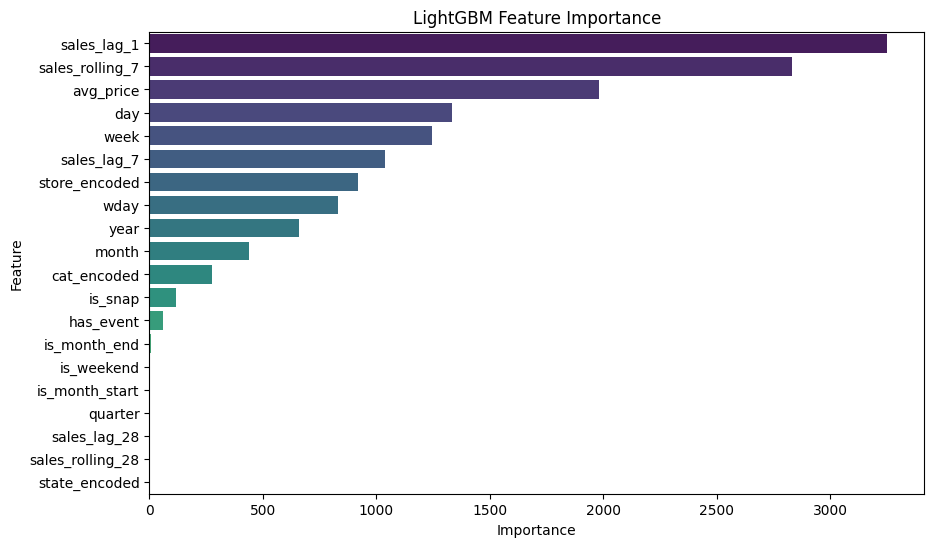

Top 10 Important Features:
            Feature  Importance
12      sales_lag_1        3253
15  sales_rolling_7        2832
11        avg_price        1983
3               day        1335
4              week        1244
13      sales_lag_7        1038
18    store_encoded         921
2              wday         830
1              year         660
0             month         437


In [4]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_lgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, palette='viridis')
plt.title("LightGBM Feature Importance")
plt.show()

print("Top 10 Important Features:")
print(feature_importance.head(10))

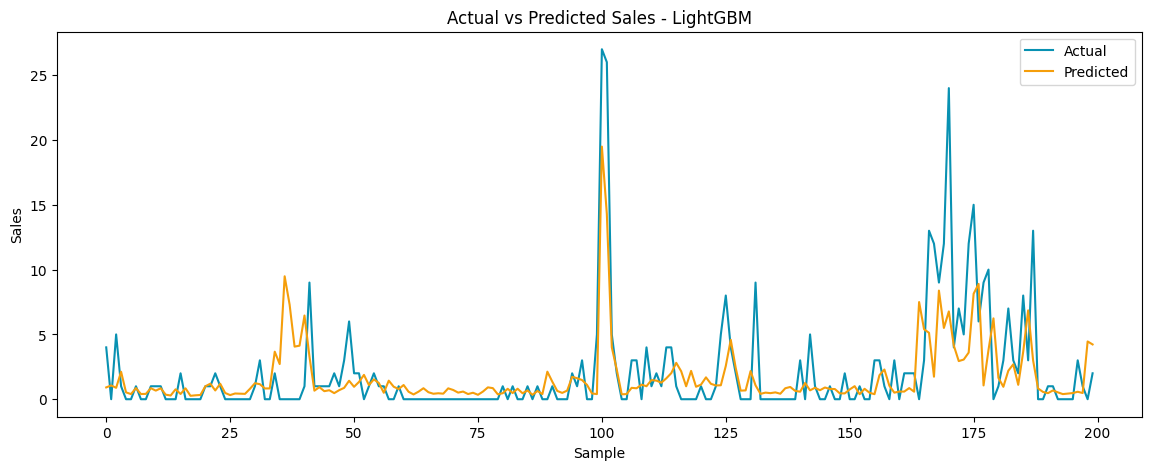

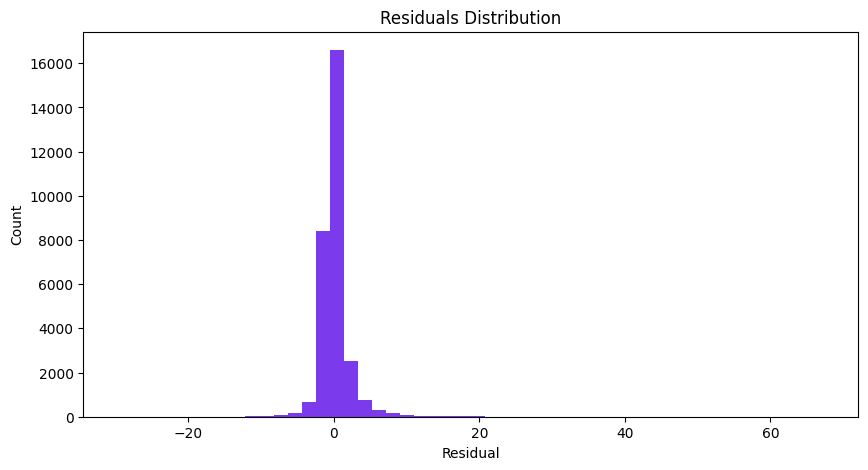

Average Residual: 0.12
Std Residual: 2.49


In [5]:
# Actual vs Predicted Plot
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:200], label='Actual', color='#0891B2')
plt.plot(y_pred[:200], label='Predicted', color='#F59E0B')
plt.title("Actual vs Predicted Sales - LightGBM")
plt.xlabel("Sample")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Residuals plot
residuals = y_test.values - y_pred
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=50, color='#7C3AED')
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

print("Average Residual:", round(residuals.mean(), 2))
print("Std Residual:", round(residuals.std(), 2))

In [6]:
# Save model
import pickle

with open("../models/lightgbm_model.pkl", "wb") as f:
    pickle.dump(model_lgb, f)

print("LightGBM model saved!")

print("\n" + "="*50)
print("LIGHTGBM FORECASTING SUMMARY")
print("="*50)
print("Model: LightGBM Regressor")
print("Training Rows: 469,976")
print("Testing Rows: 30,024")
print("Features Used: 20")
print("\nModel Performance:")
print("MAE: 1.2")
print("RMSE: 2.49")
print("Average Residual: 0.12")
print("\nTop 3 Important Features:")
print("1. sales_lag_1")
print("2. sales_rolling_7")
print("3. avg_price")
print("\nComparison with Prophet:")
print("Prophet MAE: 12.0  vs  LightGBM MAE: 1.2")
print("LightGBM is 10x better than Prophet!")
print("="*50)

LightGBM model saved!

LIGHTGBM FORECASTING SUMMARY
Model: LightGBM Regressor
Training Rows: 469,976
Testing Rows: 30,024
Features Used: 20

Model Performance:
MAE: 1.2
RMSE: 2.49
Average Residual: 0.12

Top 3 Important Features:
1. sales_lag_1
2. sales_rolling_7
3. avg_price

Comparison with Prophet:
Prophet MAE: 12.0  vs  LightGBM MAE: 1.2
LightGBM is 10x better than Prophet!
